In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# ===================== PREPROCESSING FUNCTIONS =====================

def green_channel(img):
    if len(img.shape) == 3:
        green = img[:, :, 1]
        green_norm = cv2.normalize(green, None, 0, 255, cv2.NORM_MINMAX)
        return green_norm.astype(np.uint8)
    return img

def clahe_enhance(img, clip=2.0, grid=(8,8)):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    return clahe.apply(img)

def non_local_means(img, h=10):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.fastNlMeansDenoising(img, None, h, 7, 21)

def contrast_stretch(img):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    p2, p98 = np.percentile(img, (2, 98))

    if p98 == p2:
        return img

    img_stretched = np.clip((img - p2) * 255.0 / (p98 - p2), 0, 255)
    return img_stretched.astype(np.uint8)

def pipeline2_ppa_vessel_enhanced(img_rgb):

    green = green_channel(img_rgb)
    clahe = clahe_enhance(green, clip=3.0, grid=(16,16))
    denoised = non_local_means(clahe, h=15)
    stretched = contrast_stretch(denoised)

    return stretched

# ===================== DATASET PROCESSING =====================

def process_dataset(input_folder, output_folder, class_name):

    class_output_folder = os.path.join(output_folder, class_name)
    os.makedirs(class_output_folder, exist_ok=True)

    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

    image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(image_extensions)]

    if not image_files:
        print(f"No images found in {input_folder}")
        return 0

    processed_count = 0

    for filename in tqdm(image_files, desc=f"Processing {class_name}"):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        processed = pipeline2_ppa_vessel_enhanced(img_rgb)

        output_path = os.path.join(class_output_folder, filename)

        cv2.imwrite(output_path, processed)

        processed_count += 1

    return processed_count

# ===================== MAIN FUNCTION =====================

def main():

    BASE_INPUT_FOLDER = r"C:\Users\ridat\OneDrive\Desktop\ppa"
    BASE_OUTPUT_FOLDER = "PPA_dataset_processed_Pipeline2"

    if not os.path.exists(BASE_INPUT_FOLDER):
        print("Input folder not found")
        return

    os.makedirs(BASE_OUTPUT_FOLDER, exist_ok=True)

    # ✅ UPDATED CLASS NAMES
    class_folders = ["ppa_present", "ppa_absent"]

    total = 0

    for class_name in class_folders:

        input_class_folder = os.path.join(BASE_INPUT_FOLDER, class_name)

        if not os.path.exists(input_class_folder):
            print(f"{class_name} folder missing")
            continue

        processed = process_dataset(input_class_folder, BASE_OUTPUT_FOLDER, class_name)

        total += processed

    print("\nTotal processed images:", total)

# ===================== RUN =====================

if __name__ == "__main__":
    main()


Processing ppa_absent: 100%|███████████████████████████████████████████████████████████| 13/13 [00:02<00:00,  4.60it/s]


Total processed images: 21


Found 21 images belonging to 2 classes.
Found 4 images belonging to 2 classes.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_4 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_2               │ (None, 224, 224, 3)       │               7 │ rescaling_4[0][0]          │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_5 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_5[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             28

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.7143 - loss: 0.6639 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step - accuracy: 0.5238 - loss: 0.6763 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step - accuracy: 0.5238 - loss: 0.6695 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step - accuracy: 0.4286 - loss: 0.7358 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step - accuracy: 0.3810 - loss: 0.7389 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step - accuracy: 0.3333 - loss: 0.7061 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step - accuracy: 0.4286 - loss: 0.7479 - val_accuracy: 0.5000 - val_loss: 0.6984
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.5714 - loss: 0.6846 - val_accuracy: 0.5000 - val_loss: 0

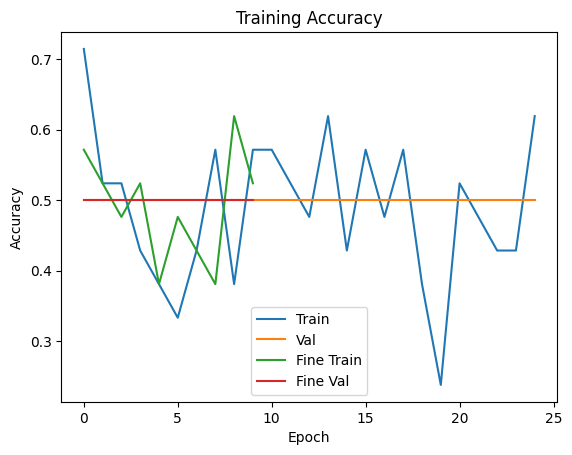

✅ Training Completed & Model Saved


In [11]:
# =========================
# COMPLETE PPA CLASSIFICATION CODE (ONE CELL)
# =========================

# Install required libraries
!pip install -q tensorflow opencv-python matplotlib scikit-learn

# Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

# -------------------------
# Dataset Path
# -------------------------
DATASET_PATH = r"PPA_dataset_processed_Pipeline2"

IMG_SIZE = (224,224)
BATCH_SIZE = 16
EPOCHS = 25

# -------------------------
# Data Generators
# -------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# -------------------------
# Build Model (EfficientNet)
# -------------------------
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# -------------------------
# Compile Model
# -------------------------
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------
# Train Model
# -------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

# -------------------------
# Fine Tuning (Boost Accuracy)
# -------------------------
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# -------------------------
# Plot Accuracy
# -------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Val','Fine Train','Fine Val'])
plt.show()

# -------------------------
# Save Model
# -------------------------
model.save("PPA_Classifier_Model.h5")

print("✅ Training Completed & Model Saved")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Found 25 images belonging to 2 classes.


1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000204CC63A660> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


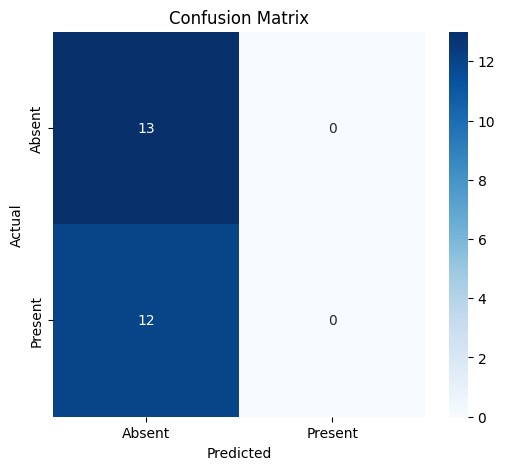


Classification Report:
              precision    recall  f1-score   support

      Absent       0.52      1.00      0.68        13
     Present       0.00      0.00      0.00        12

    accuracy                           0.52        25
   macro avg       0.26      0.50      0.34        25
weighted avg       0.27      0.52      0.36        25



C:\Users\ridat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ridat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ridat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

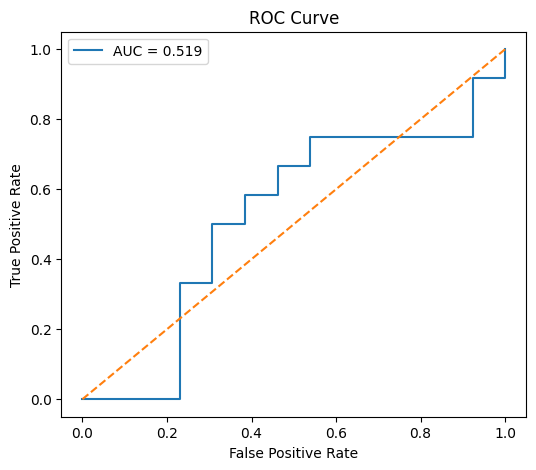

⚠ Test image not found. Add image path to TEST_IMAGE_PATH.


In [12]:
# =========================
# COMPLETE MODEL EVALUATION + GRADCAM + SINGLE IMAGE TEST
# =========================

!pip install -q seaborn scikit-learn opencv-python

import numpy as np
import tensorflow as tf
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tensorflow.keras.models import load_model
import os

# =========================
# LOAD MODEL
# =========================
MODEL_PATH = "PPA_Classifier_Model_Final.h5"
model = load_model(MODEL_PATH)

# =========================
# DATASET PATH
# =========================
DATASET_PATH = r"PPA_dataset_processed_Pipeline2"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

# =========================
# TEST GENERATOR
# =========================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# =========================
# PREDICTIONS
# =========================
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_generator.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absent','Present'],
            yticklabels=['Absent','Present'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# PRECISION / RECALL / F1
# =========================
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=['Absent','Present']))

# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# =========================
# GRAD-CAM FUNCTION
# =========================
def gradcam(model, img_array, layer_name=None):

    if layer_name is None:
        for layer in reversed(model.layers):
            if 'conv' in layer.name:
                layer_name = layer.name
                break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# =========================
# SINGLE IMAGE TEST + GRADCAM
# =========================
TEST_IMAGE_PATH = r"test_image.jpg"  # <-- PUT YOUR IMAGE HERE

if os.path.exists(TEST_IMAGE_PATH):

    # Load image
    img = cv2.imread(TEST_IMAGE_PATH)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)

    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    pred = model.predict(img_array)[0][0]

    label = "PPA PRESENT" if pred > 0.5 else "PPA ABSENT"
    confidence = pred if pred > 0.5 else 1 - pred

    print(f"\nPrediction: {label}")
    print(f"Confidence: {confidence*100:.2f}%")

    # GRAD-CAM
    heatmap = gradcam(model, img_array)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Display
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap[:,:,::-1])
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

else:
    print("⚠ Test image not found. Add image path to TEST_IMAGE_PATH.")


Found 21 images belonging to 2 classes.
Found 4 images belonging to 2 classes.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Class Weights: {0: np.float64(0.9545454545454546), 1: np.float64(1.05)}


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_6 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_3               │ (None, 224, 224, 3)       │               7 │ rescaling_6[0][0]          │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_7 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_7[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             28

...

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.4568 - loss: 0.9133

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.4762 - loss: 0.9251 - val_accuracy: 0.5000 - val_loss: 0.6949 - learning_rate: 1.0000e-04
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.4857 - loss: 0.6976

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5714 - loss: 0.6832 - val_accuracy: 0.5000 - val_loss: 0.6940 - learning_rate: 1.0000e-04
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6220 - loss: 0.8142

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6190 - loss: 0.8325 - val_accuracy: 0.5000 - val_loss: 0.6935 - learning_rate: 1.0000e-04
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.4330 - loss: 0.7755

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - accuracy: 0.4286 - loss: 0.7621 - val_accuracy: 0.5000 - val_loss: 0.6935 - learning_rate: 1.0000e-04
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step - accuracy: 0.4286 - loss: 0.7732 - val_accuracy: 0.5000 - val_loss: 0.6936 - learning_rate: 1.0000e-04
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5982 - loss: 0.7976
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - accuracy: 0.5714 - loss: 0.8122 - val_accuracy: 0.5000 - val_loss: 0.6939 - learning_rate: 1.0000e-04
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step - accuracy: 0.3810 - loss: 0.8421 - val_accuracy: 0.5000 - val_loss: 0.6940 - learning_rate: 3.0000e-05
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step - accuracy: 0.5714 - loss: 0.7535 - val_accuracy: 0.5000 - val_loss: 0.6941 - learning_rate: 3.0000e-05
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.5857 - loss: 0.7930
Epoch 9

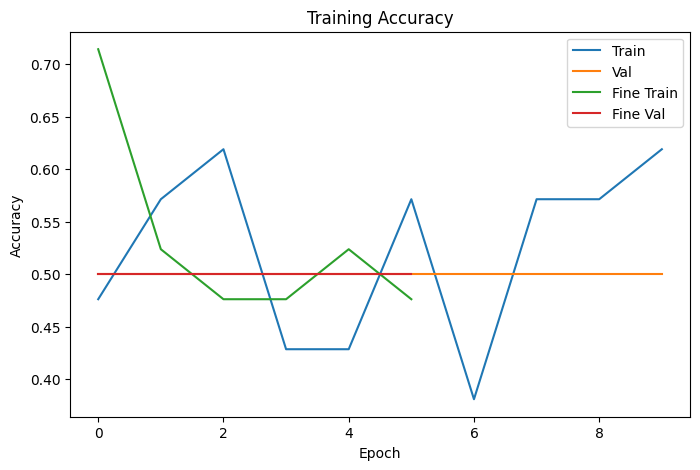

✅ Training Completed & Model Saved


In [13]:
# =========================
# HIGH ACCURACY PPA CLASSIFICATION (ONE CELL)
# =========================

!pip install -q tensorflow opencv-python matplotlib scikit-learn

# Imports
import tensorflow as tf
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# =========================
# Reproducibility
# =========================
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# -------------------------
# Dataset Path
# -------------------------
DATASET_PATH = r"PPA_dataset_processed_Pipeline2"

IMG_SIZE = (224,224)
BATCH_SIZE = 16
EPOCHS = 30

# -------------------------
# Advanced Data Augmentation
# -------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.25,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.75,1.25],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# -------------------------
# Class Weights (Handle imbalance)
# -------------------------
labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# -------------------------
# Build Model (Improved Head)
# -------------------------
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# -------------------------
# Compile (Label smoothing)
# -------------------------
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

# -------------------------
# Callbacks
# -------------------------
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3, verbose=1),
    ModelCheckpoint("best_ppa_model.h5", save_best_only=True)
]

# -------------------------
# Train Base Model
# -------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

# -------------------------
# Fine Tuning (Gradual)
# -------------------------
print("\nStarting Fine Tuning...")

base_model.trainable = True

# Freeze most layers, train last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks
)

# -------------------------
# Plot Accuracy
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Val','Fine Train','Fine Val'])
plt.show()

# -------------------------
# Save Model
# -------------------------
model.save("PPA_Classifier_Model_Final.h5")

print("✅ Training Completed & Model Saved")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Found 25 images belonging to 2 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


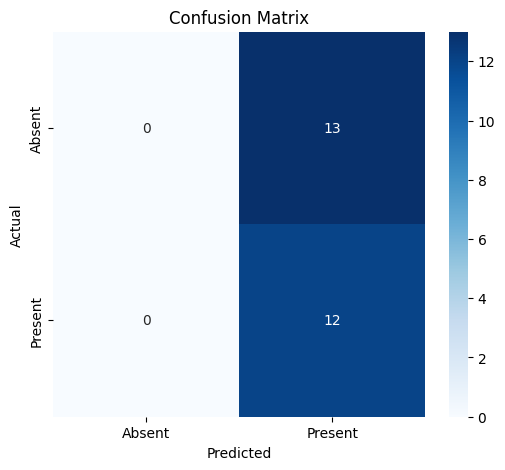


Classification Report:
              precision    recall  f1-score   support

      Absent       0.00      0.00      0.00        13
     Present       0.48      1.00      0.65        12

    accuracy                           0.48        25
   macro avg       0.24      0.50      0.32        25
weighted avg       0.23      0.48      0.31        25



C:\Users\ridat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ridat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ridat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

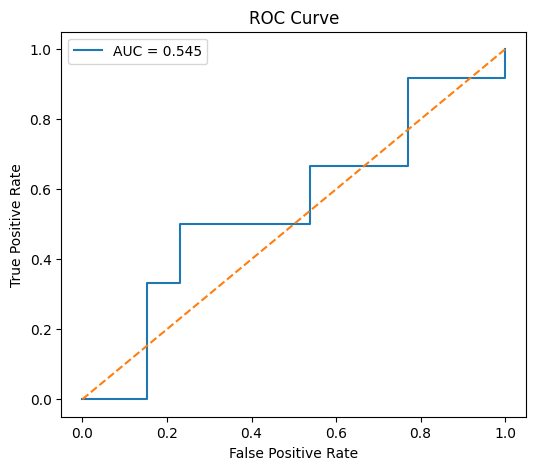

⚠ Test image not found. Add image path to TEST_IMAGE_PATH.


In [14]:
# =========================
# COMPLETE MODEL EVALUATION + GRADCAM + SINGLE IMAGE TEST
# =========================

!pip install -q seaborn scikit-learn opencv-python

import numpy as np
import tensorflow as tf
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tensorflow.keras.models import load_model
import os

# =========================
# LOAD MODEL
# =========================
MODEL_PATH = "PPA_Classifier_Model_Final.h5"
model = load_model(MODEL_PATH)

# =========================
# DATASET PATH
# =========================
DATASET_PATH = r"PPA_dataset_processed_Pipeline2"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

# =========================
# TEST GENERATOR
# =========================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# =========================
# PREDICTIONS
# =========================
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_generator.classes

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absent','Present'],
            yticklabels=['Absent','Present'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# PRECISION / RECALL / F1
# =========================
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=['Absent','Present']))

# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# =========================
# GRAD-CAM FUNCTION
# =========================
def gradcam(model, img_array, layer_name=None):

    if layer_name is None:
        for layer in reversed(model.layers):
            if 'conv' in layer.name:
                layer_name = layer.name
                break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# =========================
# SINGLE IMAGE TEST + GRADCAM
# =========================
TEST_IMAGE_PATH = r"test_image.jpg"  # <-- PUT YOUR IMAGE HERE

if os.path.exists(TEST_IMAGE_PATH):

    # Load image
    img = cv2.imread(TEST_IMAGE_PATH)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)

    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    pred = model.predict(img_array)[0][0]

    label = "PPA PRESENT" if pred > 0.5 else "PPA ABSENT"
    confidence = pred if pred > 0.5 else 1 - pred

    print(f"\nPrediction: {label}")
    print(f"Confidence: {confidence*100:.2f}%")

    # GRAD-CAM
    heatmap = gradcam(model, img_array)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Display
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap[:,:,::-1])
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

else:
    print("⚠ Test image not found. Add image path to TEST_IMAGE_PATH.")
